In [17]:
# paquetes necesarios
import matplotlib.pyplot as plt
import numpy as np

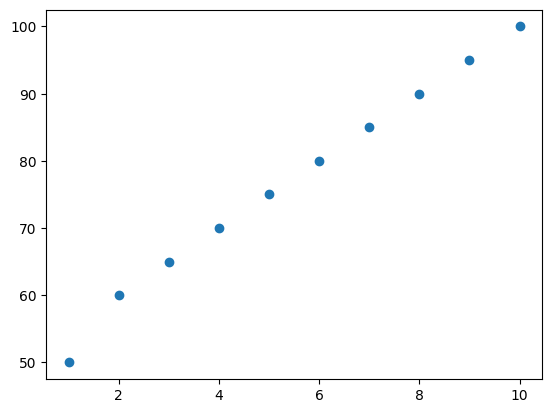

In [2]:
# Datos de horas de estudio y calificaciones finales
horas_de_estudio = [2, 3, 5, 1, 6, 4, 7, 8, 9, 10]
calificaciones_finales = [60, 65, 75, 50, 80, 70, 85, 90, 95, 100]


# Creamos el diagrama de dispersión por medio de la función plt.scatter

plt.scatter(horas_de_estudio, calificaciones_finales)

plt.show()





In [18]:
resultados = np.corrcoef(horas_de_estudio, calificaciones_finales)
print(resultados)

[[1.         0.99645179]
 [0.99645179 1.        ]]


# Ejemplo con una base de datos

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "ObesityDataSet_raw_and_data_sinthetic.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "fatemehmehrparvar/obesity-levels",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



/tmp/ipykernel_6543/258697175.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 257k/257k [00:00<00:00, 1.39MB/s]


In [4]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Text(0, 0.5, 'Weight')

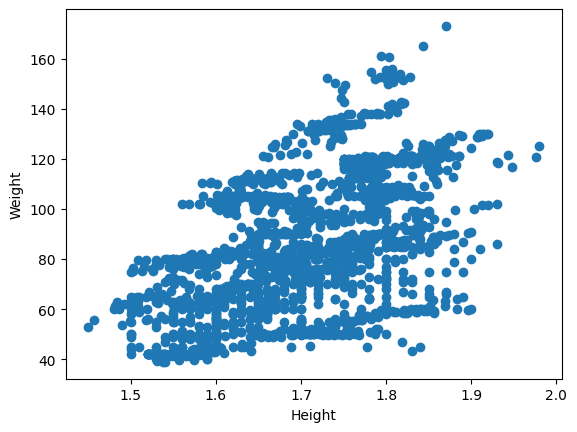

In [14]:
height = df['Height']
weight = df['Weight']

plt.scatter(height, weight)
plt.xlabel('Height')
plt.ylabel('Weight')



In [16]:
correlacion = df['Height'].corr(df['Weight'])
print(correlacion)

0.4631361166156267


# Actividad:
Realicemos un diagrama de cajas para cada grupo poblacional hombre y mujeres por separado de la variable peso .

Variables: 'Gender' y 'Weight'

/tmp/ipykernel_6543/1787363340.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(pesos,labels = ['Mujeres', 'Hombres'],vert = False)


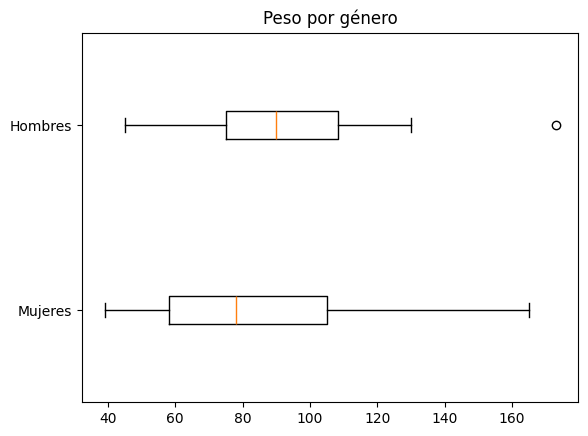

In [20]:
peso_mujeres = df[df['Gender'] == 'Female']['Weight']
peso_hombres = df[df['Gender'] == 'Male']['Weight']

pesos = [peso_mujeres, peso_hombres]

plt.boxplot(pesos,labels = ['Mujeres', 'Hombres'],vert = False)
plt.title('Peso por género')
plt.show()

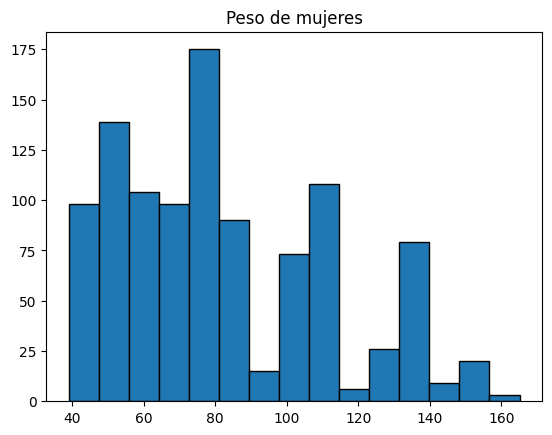

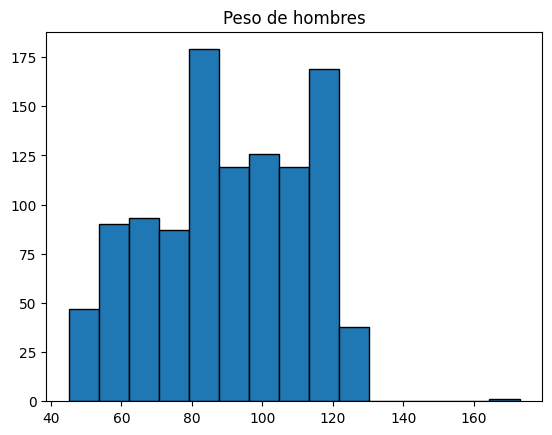

In [28]:
# Realicemos un histograma para el peso de las mujeres y de los hombres

plt.hist(peso_mujeres,bins = 15,edgecolor = 'black')
plt.title('Peso de mujeres')
plt.show()

plt.hist(peso_hombres,bins = 15,  edgecolor = 'black')
plt.title('Peso de hombres')
plt.show()


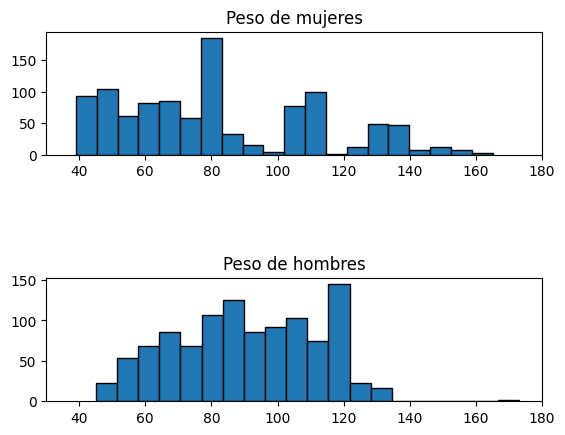

In [39]:
fig, ax = plt.subplots(2,1)

ax[0].hist(peso_mujeres,bins = 20,edgecolor = 'black')
ax[0].set_title('Peso de mujeres')
ax[1].hist(peso_hombres,bins = 20,  edgecolor = 'black')
ax[1].set_title('Peso de hombres')
plt.subplots_adjust(hspace=1)
# Establecemos los mismos límites en el eje x para ambos subplots

ax[0].set_xlim(30, 180)
ax[1].set_xlim(30, 180)


plt.show()

In [40]:
# Hallemos media y desviación
#estándar de el peso de los hombre y de las mujeres


peso_mujeres = df[df['Gender'] == 'Female']['Weight']
peso_hombres = df[df['Gender'] == 'Male']['Weight']


promedio_peso_mujeres = np.mean(peso_mujeres)
promedio_peso_hombres = np.mean(peso_hombres)
print(f"El promedio de peso de las mujeres es: {promedio_peso_mujeres}")
print(f'El promedio de peso de los hombres es: {promedio_peso_hombres}')

El promedio de peso de las mujeres es: 82.30236417353788
El promedio de peso de los hombres es: 90.7694783445693


In [42]:
df['Height'].describe()

,Height
count,2111.000000
mean,1.701677
std,0.093305
min,1.450000
25%,1.630000
50%,1.700499
75%,1.768464
max,1.980000


In [43]:
import seaborn as sns


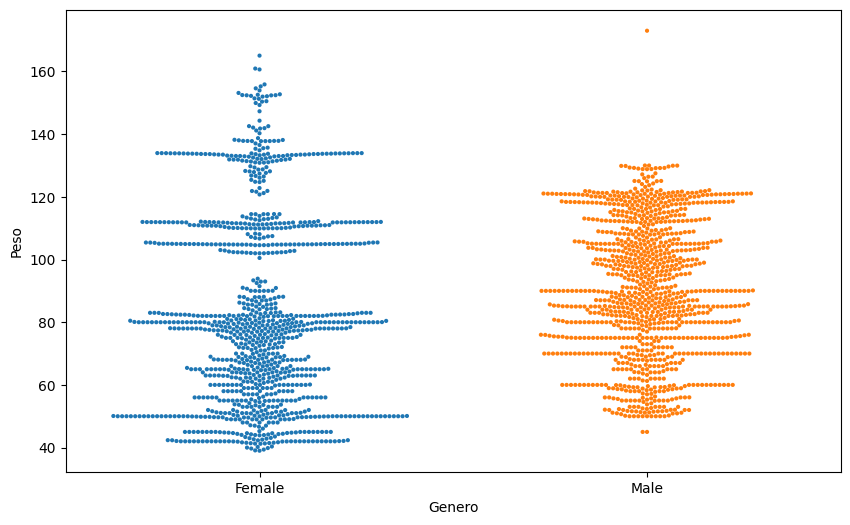

In [48]:
plt.figure(figsize=(10, 6))  # Cambia el tamaño a 10 unidades de ancho y 6 de alto




# Create bee swarm plot with Seaborn's default settings
_ = sns.swarmplot(x= 'Gender', y= 'Weight', data =df, hue ='Gender', size=3)

# Label the axes
_ = plt.xlabel('Genero')
_ = plt.ylabel('Peso')
# Show the plot
plt.show()

In [57]:
data_smoke =df['SMOKE']
freq = data_smoke.value_counts()
print(freq)

SMOKE
no     2067
yes      44
Name: count, dtype: int64


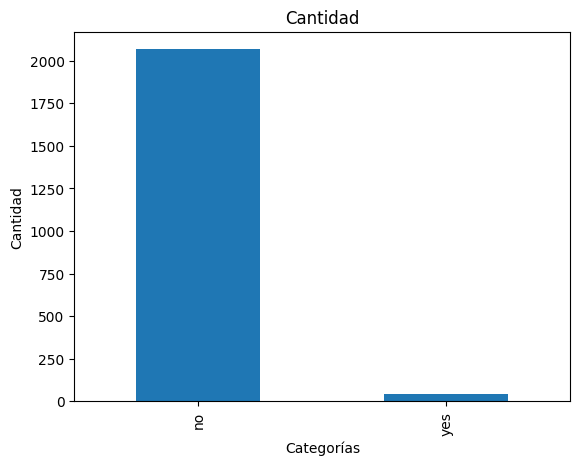

In [59]:
freq.plot(kind = 'bar')
plt.title('Cantidad')
plt.xlabel('Categorías')
plt.ylabel('Cantidad')
plt.show()